In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn 
import seaborn as sns

In [20]:
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


<Axes: xlabel='wt', ylabel='mpg'>

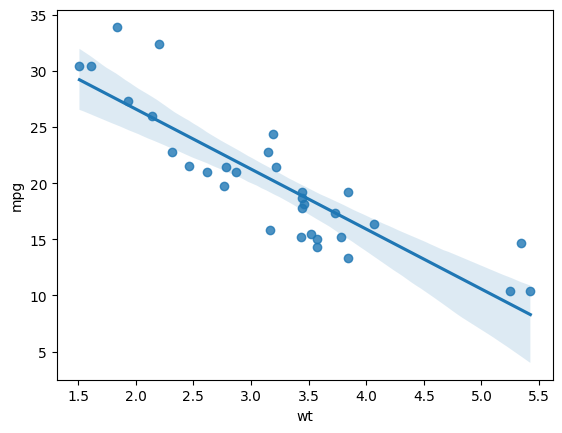

In [21]:
sns.regplot(cars, x="wt", y="mpg")

In [22]:
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1, 1)
y_list = cars.mpg.values
y_np = np.array(y_list, dtype=np.float32).reshape(-1, 1)


In [23]:

X = torch.tensor(cars.loc[:,'wt'].to_numpy(), dtype=torch.float32).unsqueeze(1)
y_true = torch.tensor(cars['mpg'].to_numpy(), dtype=torch.float32).unsqueeze(1)


I’ll clarify when dot-access like cars.wt is fine vs when you should prefer bracket or .loc, and suggest a safe pattern for your PyTorch prep.

- cars.wt vs cars['wt']
  - cars.wt is just convenience sugar for cars['wt'].
  - It only works when the column name is a valid Python identifier (no spaces, punctuation, leading digits) and doesn’t clash with a DataFrame attribute/method (e.g., count, min).
  - It’s brittle in refactors and can silently break or shadow attributes. For robust code, prefer cars['wt'] (and for slices/filters, .loc).

- .loc usage
  - Use .loc[row_labels, col_labels] for explicit, label-based selection; it’s the most reliable for filtering, multiple columns, and avoiding SettingWithCopy issues.
  - Example: cars.loc[:, 'wt'] or cars.loc[:, ['wt']].

- .values vs .to_numpy()
  - .values works but is discouraged; prefer .to_numpy() which respects extension dtypes and is clearer.
  - For PyTorch, also get shapes right: models expect 2D features (n, 1). Either reshape the NumPy array or unsqueeze the tensor.

- Recommended, tidy and safe for your notebook
  - Using NumPy:
    - X = cars[['wt']].to_numpy(dtype=np.float32)  // shape (n, 1)
    - y = cars[['mpg']].to_numpy(dtype=np.float32)
  - Or directly to torch:
    - X = torch.tensor(cars['wt'].to_numpy(), dtype=torch.float32).unsqueeze(1)
    - y = torch.tensor(cars['mpg'].to_numpy(), dtype=torch.float32).unsqueeze(1)

Bottom line: Dot-access is okay for quick exploration when the name is clean and non-conflicting. For best practices and production-quality code, use bracket indexing or .loc and prefer .to_numpy() over .values.

Task: Clarify whether passing a NumPy array to torch.tensor is “passing directly to torch,” and how that differs from using tensors in a model.

- Yes: torch.tensor(cars['wt'].to_numpy(), dtype=torch.float32).unsqueeze(1) is valid. You’re not feeding a NumPy array into the model; you’re using a Tensor factory to convert a NumPy array into a torch.Tensor first. The model sees a Tensor, not a NumPy array.

- Distinctions:
  - torch.from_numpy(np_arr): zero-copy view; shares memory; requires supported dtype and contiguous layout. Keeps NumPy’s dtype (often float64) unless you cast later.
  - torch.as_tensor(np_arr, dtype=...): avoids copy when possible; copies if needed to match dtype/device/layout.
  - torch.tensor(np_arr, dtype=...): always copies; safest and explicit.

- Practical guidance:
  - If you want zero-copy and you control dtype/shape: use from_numpy after to_numpy(dtype=np.float32).
  - If you want a simple, robust one-liner: use torch.tensor(..., dtype=torch.float32) and unsqueeze to get (n, 1).

- Recommended line (copying, robust):
  - X = torch.tensor(cars['wt'].to_numpy(), dtype=torch.float32).unsqueeze(1)
  - y = torch.tensor(cars['mpg'].to_numpy(), dtype=torch.float32).unsqueeze(1)

That’s not “passing NumPy directly to the model”—it’s converting to a Tensor first, which is exactly what PyTorch expects.

In [24]:
class LinearRegressionTorch(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        out = self.linear(x)
        return out

In [25]:
input_dim, output_dim = 1, 1
model = LinearRegressionTorch(input_dim, output_dim)

In [26]:
loss_function = nn.MSELoss()

In [ ]:
LR = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
losses, slopes, biases = [], [], []

In [43]:
NUM_EPOCHS = 1000
# Clear lists before training to avoid accumulating from previous runs
losses, slopes, biases = [], [], []

for epoch in range(NUM_EPOCHS):
    #set gradients to zero
    optimizer.zero_grad()
    y_pred = model(X)

    # compute loss
    loss = loss_function(y_pred, y_true)
    loss.backward()
    # update the weights
    optimizer.step()

    # store loss

    losses.append(np.float64(loss))

    for name, param in model.named_parameters():
        if param.requires_grad:
            if name == 'linear.weight':
                slopes.append(param.data.numpy()[0][0])
            if name == 'linear.bias':
                biases.append(param.data.numpy()[0])
    
    if epoch % 100 == 0:
        print(f"{epoch}: {loss},  {biases[-1]}, {slopes[-1]}")



0: 8.709062576293945,  36.91182327270508, -5.237259864807129
100: 8.706045150756836,  36.964515686035156, -5.252392292022705
200: 8.70382022857666,  37.009761810302734, -5.265387058258057
300: 8.702177047729492,  37.048622131347656, -5.276547431945801
400: 8.700965881347656,  37.081993103027344, -5.286132335662842
500: 8.700074195861816,  37.110660552978516, -5.2943644523620605
600: 8.69941520690918,  37.13528060913086, -5.301435947418213
700: 8.698928833007812,  37.15642547607422, -5.307508945465088
800: 8.698570251464844,  37.174583435058594, -5.3127241134643555
900: 8.698305130004883,  37.19017791748047, -5.317202568054199


In [44]:
import matplotlib
import matplotlib.pyplot as plt

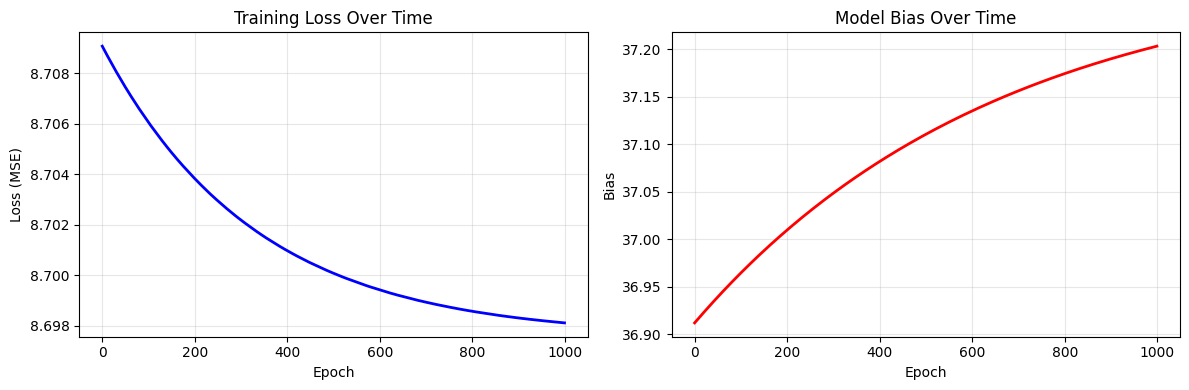

In [45]:
# Create subplots to show loss and bias evolution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss evolution
epochs = np.arange(0, len(losses))
ax1.plot(epochs, losses, 'b-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss Over Time')
ax1.grid(True, alpha=0.3)

# Plot bias evolution
ax2.plot(epochs, biases, 'r-', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Bias')
ax2.set_title('Model Bias Over Time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

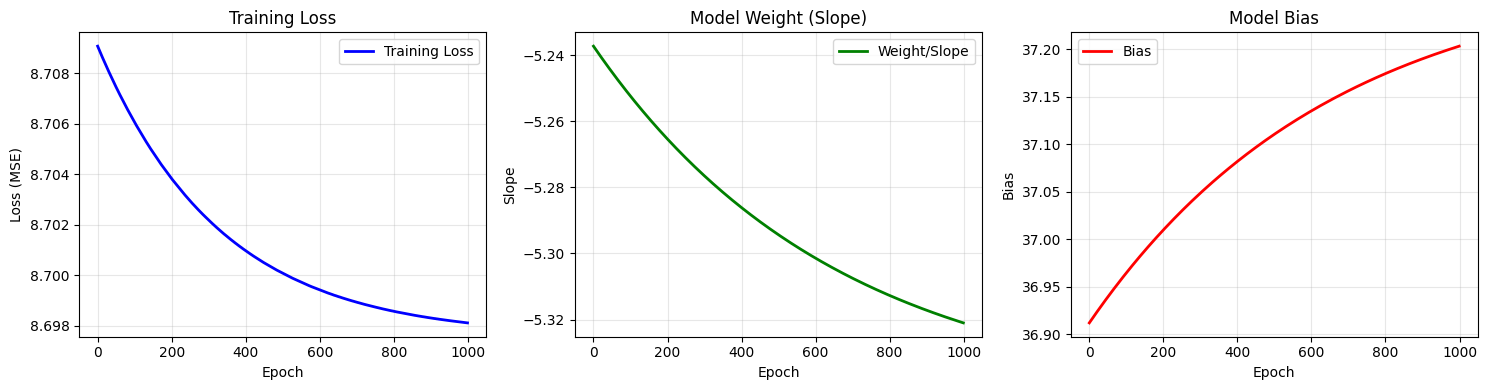

Final Loss: 8.6981
Final Slope: -5.3210
Final Bias: 37.2035


In [46]:
# Comprehensive view: Loss, Slope, and Bias evolution
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

epochs = np.arange(0, len(losses))

# Loss evolution
ax1.plot(epochs, losses, 'b-', linewidth=2, label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Slope evolution
ax2.plot(epochs, slopes, 'g-', linewidth=2, label='Weight/Slope')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Slope')
ax2.set_title('Model Weight (Slope)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Bias evolution
ax3.plot(epochs, biases, 'r-', linewidth=2, label='Bias')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Bias')
ax3.set_title('Model Bias')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# Print final values
print(f"Final Loss: {losses[-1]:.4f}")
print(f"Final Slope: {slopes[-1]:.4f}")
print(f"Final Bias: {biases[-1]:.4f}")

In [ ]:
# Create subplots to show loss and bias evolution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss evolution
epochs = np.arange(0, len(losses))
ax1.plot(X_np, losses, 'b-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss Over Time')
ax1.grid(True, alpha=0.3)

# Plot bias evolution
ax2.plot(X_np, biases, 'r-', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Bias')
ax2.set_title('Model Bias Over Time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

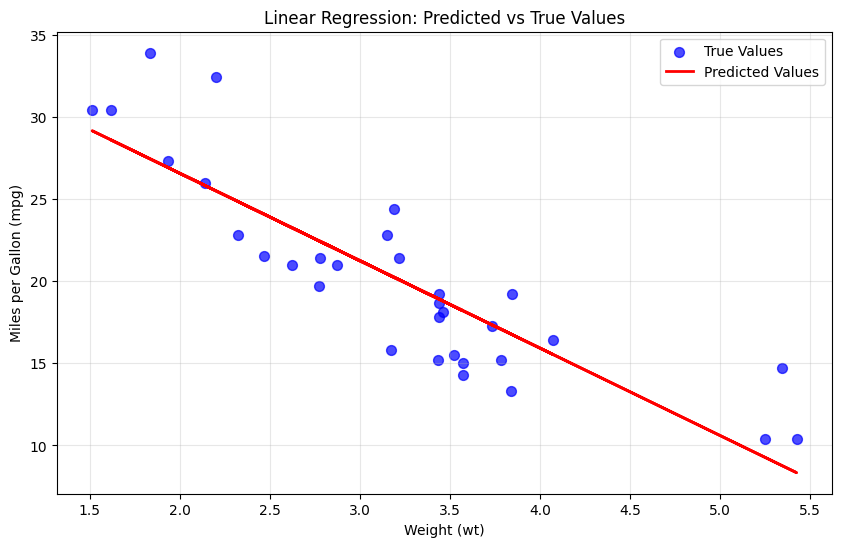

Final model parameters:
Slope: -5.3210
Bias: 37.2035


In [47]:
# Generate predictions for plotting
with torch.no_grad():
    y_pred = model(X)

# Plot y_pred and y_true as a function of X
plt.figure(figsize=(10, 6))
plt.scatter(X.numpy(), y_true.numpy(), alpha=0.7, label='True Values', color='blue', s=50)
plt.plot(X.numpy(), y_pred.numpy(), 'r-', linewidth=2, label='Predicted Values')
plt.xlabel('Weight (wt)')
plt.ylabel('Miles per Gallon (mpg)')
plt.title('Linear Regression: Predicted vs True Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print model parameters
print(f"Final model parameters:")
for name, param in model.named_parameters():
    if name == 'linear.weight':
        print(f"Slope: {param.data.numpy()[0][0]:.4f}")
    if name == 'linear.bias':
        print(f"Bias: {param.data.numpy()[0]:.4f}")

In [48]:
# Let's demonstrate what MSELoss returns when given vectors
print("=== Understanding MSELoss Output ===")

# Create a simple example with known values
example_pred = torch.tensor([[2.0], [4.0], [6.0]], dtype=torch.float32)
example_true = torch.tensor([[1.0], [3.0], [5.0]], dtype=torch.float32)

print(f"Predicted values shape: {example_pred.shape}")
print(f"True values shape: {example_true.shape}")
print(f"Predicted values: {example_pred.flatten()}")
print(f"True values: {example_true.flatten()}")

# Calculate MSE loss
mse_loss = nn.MSELoss()
loss_result = mse_loss(example_pred, example_true)

print(f"\nLoss result type: {type(loss_result)}")
print(f"Loss result shape: {loss_result.shape}")
print(f"Loss result value: {loss_result}")

# Manual calculation to verify
squared_diffs = (example_pred - example_true) ** 2
print(f"\nSquared differences: {squared_diffs.flatten()}")
manual_mse = squared_diffs.mean()
print(f"Manual MSE calculation: {manual_mse}")

print(f"\nVerification: {loss_result.item()} == {manual_mse.item()} ? {abs(loss_result.item() - manual_mse.item()) < 1e-6}")

# Now let's check with your actual data
print(f"\n=== Your Model's Current Loss ===")
with torch.no_grad():
    current_pred = model(X)
    current_loss = loss_function(current_pred, y_true)
    print(f"Current prediction shape: {current_pred.shape}")
    print(f"Current true values shape: {y_true.shape}")
    print(f"Current loss type: {type(current_loss)}")
    print(f"Current loss shape: {current_loss.shape}")
    print(f"Current loss value: {current_loss.item():.6f}")
    
print(f"\nSo the loss function returns a SCALAR (single number), not a vector!")

=== Understanding MSELoss Output ===
Predicted values shape: torch.Size([3, 1])
True values shape: torch.Size([3, 1])
Predicted values: tensor([2., 4., 6.])
True values: tensor([1., 3., 5.])

Loss result type: <class 'torch.Tensor'>
Loss result shape: torch.Size([])
Loss result value: 1.0

Squared differences: tensor([1., 1., 1.])
Manual MSE calculation: 1.0

Verification: 1.0 == 1.0 ? True

=== Your Model's Current Loss ===
Current prediction shape: torch.Size([32, 1])
Current true values shape: torch.Size([32, 1])
Current loss type: <class 'torch.Tensor'>
Current loss shape: torch.Size([])
Current loss value: 8.698111

So the loss function returns a SCALAR (single number), not a vector!


## PyTorch Early Stopping Methods

**PyTorch Core**: No built-in early stopping in pure PyTorch. You implement it manually by tracking validation loss and stopping when it stops improving.

**PyTorch Lightning**: Has built-in `EarlyStopping` callback that handles this automatically.

**Manual Implementation**: Track validation loss, compare with best seen so far, and stop after patience epochs without improvement.

### Available Approaches:

1. **PyTorch Lightning EarlyStopping** (Recommended for complex projects)
2. **Manual Early Stopping** (Good for learning and simple cases)
3. **Third-party libraries** (like Skorch for scikit-learn integration)

Let's see both approaches in action:

In [56]:
# ===========================
# MANUAL EARLY STOPPING EXAMPLE
# ===========================

# Reset model for fresh training with early stopping
class LinearRegressionTorch(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)

# Create fresh model
input_dim, output_dim = 1, 1
model_early = LinearRegressionTorch(input_dim, output_dim)

# Setup training components
loss_function = nn.MSELoss()
LR = 0.05
optimizer = torch.optim.SGD(model_early.parameters(), lr=LR)

# Split data for validation (simple split for demo)
split_idx = int(0.8 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y_true[:split_idx], y_true[split_idx:]

print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")

Training samples: 25, Validation samples: 7


In [57]:
# Manual Early Stopping Implementation
MAX_EPOCHS = 2000
PATIENCE = 50  # Stop if no improvement for 50 epochs
MIN_DELTA = 1e-6  # Minimum change to qualify as improvement

# Track training progress
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print("Training with Manual Early Stopping...")
print(f"Max epochs: {MAX_EPOCHS}, Patience: {PATIENCE}, Min delta: {MIN_DELTA}")
print("-" * 60)

for epoch in range(MAX_EPOCHS):
    # Training phase
    model_early.train()
    optimizer.zero_grad()
    y_pred_train = model_early(X_train)
    train_loss = loss_function(y_pred_train, y_train)
    train_loss.backward()
    optimizer.step()
    
    # Validation phase
    model_early.eval()
    with torch.no_grad():
        y_pred_val = model_early(X_val)
        val_loss = loss_function(y_pred_val, y_val)
    
    # Store losses
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    
    # Early stopping logic
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss.item()
        patience_counter = 0
        # Save best model state
        best_model_state = model_early.state_dict().copy()
        improvement = "✓"
    else:
        patience_counter += 1
        improvement = ""
    
    # Print progress every 100 epochs
    if epoch % 100 == 0 or patience_counter == 0:
        print(f"Epoch {epoch:4d}: Train Loss: {train_loss.item():.6f}, "
              f"Val Loss: {val_loss.item():.6f}, "
              f"Patience: {patience_counter:2d}/{PATIENCE} {improvement}")
    
    # Early stopping check
    if patience_counter >= PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch}")
        print(f"Best validation loss: {best_val_loss:.6f}")
        break

# Restore best model
if best_model_state is not None:
    model_early.load_state_dict(best_model_state)
    print(f"✅ Model restored to best state (val_loss: {best_val_loss:.6f})")

print(f"\nTraining completed! Final epoch: {epoch}")
print(f"Total epochs run: {len(train_losses)}")
print(f"Early stopping saved: {MAX_EPOCHS - len(train_losses)} epochs")

Training with Manual Early Stopping...
Max epochs: 2000, Patience: 50, Min delta: 1e-06
------------------------------------------------------------
Epoch    0: Train Loss: 510.290131, Val Loss: 114.161079, Patience:  0/50 ✓
Epoch   26: Train Loss: 79.798485, Val Loss: 113.044594, Patience:  0/50 ✓
Epoch   27: Train Loss: 78.852432, Val Loss: 111.536301, Patience:  0/50 ✓
Epoch   28: Train Loss: 77.919083, Val Loss: 110.048882, Patience:  0/50 ✓
Epoch   29: Train Loss: 76.998245, Val Loss: 108.581985, Patience:  0/50 ✓
Epoch   30: Train Loss: 76.089775, Val Loss: 107.135368, Patience:  0/50 ✓
Epoch   31: Train Loss: 75.193504, Val Loss: 105.708748, Patience:  0/50 ✓
Epoch   32: Train Loss: 74.309265, Val Loss: 104.301834, Patience:  0/50 ✓
Epoch   33: Train Loss: 73.436897, Val Loss: 102.914375, Patience:  0/50 ✓
Epoch   34: Train Loss: 72.576241, Val Loss: 101.546127, Patience:  0/50 ✓
Epoch   35: Train Loss: 71.727127, Val Loss: 100.196785, Patience:  0/50 ✓
Epoch   36: Train Loss: 7

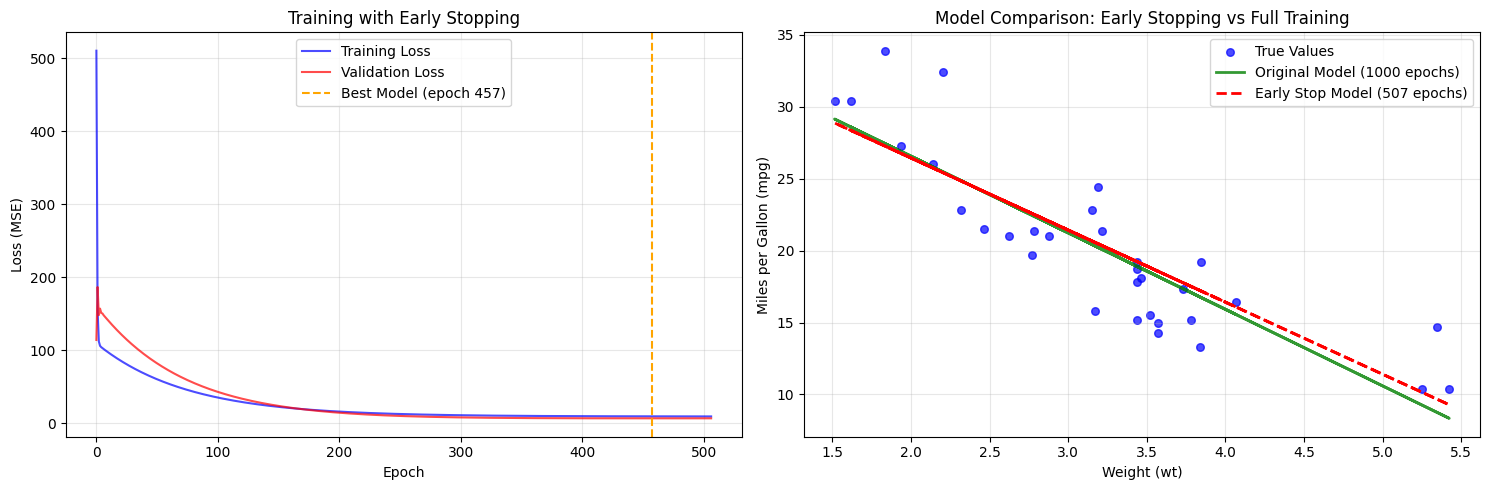


MODEL COMPARISON
Original Model (1000 epochs):
  Slope: -5.321014
  Bias:  37.203453

Early Stopping Model (507 epochs):
  Slope: -5.010356
  Bias:  36.460609

Final Loss Comparison:
  Original Model: 8.698111
  Early Stop Model: 8.863807
  Difference: 0.165696
  Epochs saved: 493 (49.3%)


In [58]:
# Visualize Early Stopping Training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(len(train_losses))

# Plot training and validation loss
ax1.plot(epochs, train_losses, 'b-', label='Training Loss', alpha=0.7)
ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', alpha=0.7)
ax1.axvline(x=len(train_losses)-PATIENCE, color='orange', linestyle='--', 
           label=f'Best Model (epoch {len(train_losses)-PATIENCE})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training with Early Stopping')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Compare final model parameters
with torch.no_grad():
    y_pred_early = model_early(X)

ax2.scatter(X.numpy(), y_true.numpy(), alpha=0.7, label='True Values', color='blue', s=30)
ax2.plot(X.numpy(), y_pred.numpy(), 'g-', linewidth=2, label='Original Model (1000 epochs)', alpha=0.8)
ax2.plot(X.numpy(), y_pred_early.numpy(), 'r--', linewidth=2, label=f'Early Stop Model ({len(train_losses)} epochs)')
ax2.set_xlabel('Weight (wt)')
ax2.set_ylabel('Miles per Gallon (mpg)')
ax2.set_title('Model Comparison: Early Stopping vs Full Training')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare model parameters
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print("Original Model (1000 epochs):")
for name, param in model.named_parameters():
    if name == 'linear.weight':
        print(f"  Slope: {param.data.numpy()[0][0]:.6f}")
    if name == 'linear.bias':
        print(f"  Bias:  {param.data.numpy()[0]:.6f}")

print(f"\nEarly Stopping Model ({len(train_losses)} epochs):")
for name, param in model_early.named_parameters():
    if name == 'linear.weight':
        print(f"  Slope: {param.data.numpy()[0][0]:.6f}")
    if name == 'linear.bias':
        print(f"  Bias:  {param.data.numpy()[0]:.6f}")

# Final losses
with torch.no_grad():
    final_loss_original = loss_function(model(X), y_true).item()
    final_loss_early = loss_function(model_early(X), y_true).item()

print(f"\nFinal Loss Comparison:")
print(f"  Original Model: {final_loss_original:.6f}")
print(f"  Early Stop Model: {final_loss_early:.6f}")
print(f"  Difference: {abs(final_loss_original - final_loss_early):.6f}")
print(f"  Epochs saved: {1000 - len(train_losses)} ({(1000 - len(train_losses))/1000*100:.1f}%)")

In [52]:
# ===========================
# PYTORCH LIGHTNING EARLY STOPPING
# ===========================

# Note: This requires PyTorch Lightning installation
# pip install pytorch-lightning

print("PyTorch Lightning EarlyStopping Example:")
print("=" * 45)

example_code = '''
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

class LitLinearRegression(pl.LightningModule):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear = nn.Linear(input_size, output_size)
        self.loss_fn = nn.MSELoss()
    
    def forward(self, x):
        return self.linear(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.loss_fn(y_pred, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.loss_fn(y_pred, y)
        self.log('val_loss', loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=0.01)

# Setup early stopping callback
early_stop_callback = EarlyStopping(
    monitor="val_loss",      # Metric to monitor
    min_delta=0.00001,       # Minimum change to qualify as improvement
    patience=10,             # Number of epochs to wait for improvement
    verbose=True,            # Print messages
    mode="min"               # "min" for loss, "max" for accuracy
)

# Create trainer with early stopping
trainer = pl.Trainer(
    max_epochs=1000,
    callbacks=[early_stop_callback],
    enable_progress_bar=True
)

# Train model
model = LitLinearRegression(input_size=1, output_size=1)
trainer.fit(model, train_dataloader, val_dataloader)

# Check how many epochs it actually ran
print(f"Stopped at epoch: {trainer.current_epoch}")
'''

print(example_code)

print("\n" + "="*60)
print("SUMMARY: PyTorch Early Stopping Options")
print("="*60)
print("1. ✅ MANUAL IMPLEMENTATION (Pure PyTorch)")
print("   - Full control over stopping logic")
print("   - Good for learning and simple projects")
print("   - Requires manual validation split and logic")
print()
print("2. ✅ PYTORCH LIGHTNING (Recommended)")
print("   - Built-in EarlyStopping callback")
print("   - Professional-grade with logging")
print("   - Handles validation automatically")
print()
print("3. ❌ PURE PYTORCH CORE")
print("   - No built-in early stopping")
print("   - Must implement manually")
print()
print("🎯 RECOMMENDATION:")
print("   - Learning/Simple: Manual implementation")
print("   - Production/Complex: PyTorch Lightning")
print("   - The manual approach above shows the core concepts!")
print("="*60)

PyTorch Lightning EarlyStopping Example:

import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

class LitLinearRegression(pl.LightningModule):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear = nn.Linear(input_size, output_size)
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.linear(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.loss_fn(y_pred, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.loss_fn(y_pred, y)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=0.01)

# Setup early stopping callback
early_stop_callback = EarlyStopping(
    moni